## Numerical

Goal : ดูการกระจายตัว (Distribution) ว่าเบ้ (Skewed) ไหม? มี Outliers ที่ต้องจัดการไหม?

### Checking Distribution

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display


In [2]:
import importlib
import sys
from pathlib import Path

# --- Configuration ---
USE_SAMPLE = True

# Resolve project root (works regardless of kernel cwd)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

# Load orders and order_products_prior using the package helpers (no hardcoded paths)
orders = data_access_module.load_quality_table("orders", use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)
order_products = data_access_module.load_quality_table("order_products_prior", use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)

# Integrity Check
match_rate = order_products["order_id"].isin(orders["order_id"]).mean()
if match_rate < 1.0:
    print(f"⚠️ Warning: ข้อมูลไม่ Match กันอยู่ {(1 - match_rate) * 100:.2f}%")

# Merge เพื่อเตรียมทำ Behavioral EDA
df = order_products.merge(orders, on="order_id", how="left")

print(f"--- Summary ({'Sample' if USE_SAMPLE else 'Full'}) ---")
print(f"Rows: {len(df):,}")
print(f"Missing after join:\n{df.isnull().sum()}")
df.head()


--- Summary (Sample) ---
Rows: 9,356
Missing after join:
order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,322,13819,1,1,36278,prior,2,1,9,7.0
1,322,432,2,1,36278,prior,2,1,9,7.0
2,322,19311,3,1,36278,prior,2,1,9,7.0
3,322,36646,4,0,36278,prior,2,1,9,7.0
4,322,28842,5,1,36278,prior,2,1,9,7.0


In [3]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

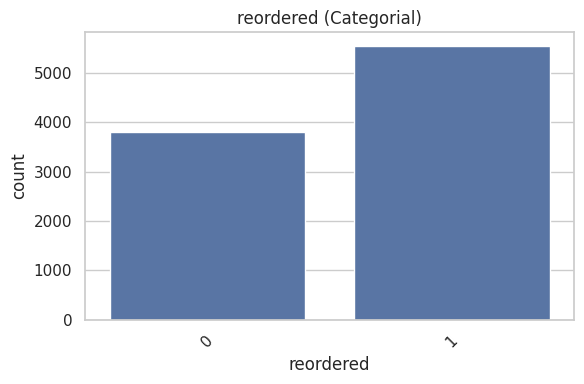

<Figure size 600x400 with 0 Axes>

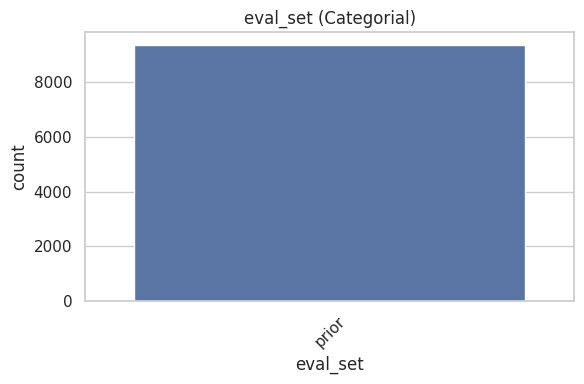

<Figure size 600x400 with 0 Axes>

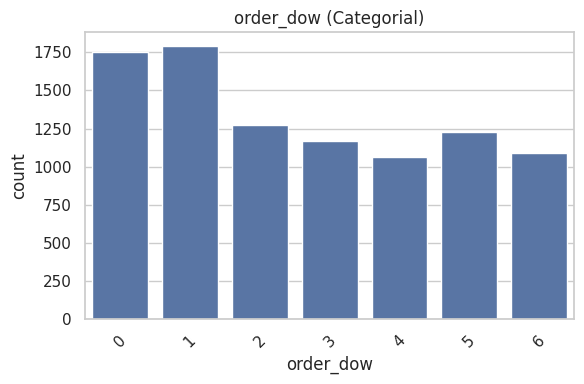

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [4]:
##Loop all columns
for col in df.columns:
    plt.figure(figsize=(6, 4))

    unique_vals = df[col].nunique()

    #Main Loop
    if df[col].dtype == "object" or unique_vals < 10:
        #Categorial
        sns.countplot(x=col, data=df)
        plt.xticks(rotation=45)
        title = f"{col} (Categorial)"
    
    elif df[col].dtype in ["int64", "float64"]:

        if unique_vals < 20:
            # discrete numeric
            sns.histplot(df[col], bins=unique_vals)
            title = f"{col} (Discrete)"
    
        else:
            continue
        
    plt.title(title)
    plt.tight_layout()
    plt.show()
